# Task3 双均线策略回测 Notebook

本 Notebook 对双均线策略的核心流程进行白盒展示，包括：数据读取、均线计算、金叉/死叉信号生成、策略回测与绩效指标评估。

## 1. 核心概念

- **金叉**：短均线向上突破长均线，通常被视为买入信号。
- **死叉**：短均线向下跌破长均线，通常被视为卖出信号。
- **累计回报**：策略在整个样本区间内累计获得的总收益。
- **最大回撤（MDD）**：策略净值从高点回落到低点时的最大跌幅。
- **夏普比率（Sharpe Ratio）**：单位风险对应的超额收益水平。

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

base_dir = Path.cwd().resolve().parent
sys.path.insert(0, str(base_dir))

from strategy_utils import StrategyParams, apply_dual_ma_strategy, load_price_data, summarize_strategy

raw_dir = base_dir / 'raw_data'
processed_dir = base_dir / 'processed_data'
figures_dir = base_dir / 'figures'
default_params = StrategyParams(short_window=5, long_window=15)
metrics_df = pd.read_csv(processed_dir / 'ma_strategy_metrics.csv')
metrics_df

,stock,short_window,long_window,sample_start,sample_end,buy_count,sell_count,benchmark_cumulative_return,strategy_cumulative_return,max_drawdown,sharpe_ratio,annualized_return
0,中国巨石（600176）,5,15,2024-01-02,2026-07-03,24,23,6.961819,2.780847,-0.284532,1.646640,0.743334
1,中国巨石（600176）,5,20,2024-01-02,2026-07-03,19,18,6.961819,3.745250,-0.218772,1.844390,0.916972
2,中国巨石（600176）,10,30,2024-01-02,2026-07-03,9,8,6.961819,3.560435,-0.282270,1.792854,0.885409
3,中际旭创（300308）,5,15,2024-01-02,2026-07-03,23,23,13.445667,4.612155,-0.597815,1.515843,1.056218
4,中际旭创（300308）,5,20,2024-01-02,2026-07-03,17,17,13.445667,9.915967,-0.522749,1.983015,1.715295
5,中际旭创（300308）,10,30,2024-01-02,2026-07-03,9,8,13.445667,6.279032,-0.354481,1.804483,1.292290


## 2. 加载样例股票并计算双均线策略

这里以中国巨石为例，展示如何从原始 CSV 开始计算短均线、长均线和交易信号。

In [2]:
jushi = load_price_data(raw_dir / 'china-jushi_600176.csv')
jushi_strategy = apply_dual_ma_strategy(jushi, default_params.short_window, default_params.long_window)
jushi_strategy[['date', 'close', 'ma_short', 'ma_long', 'buy_signal', 'sell_signal', 'position']].tail(12)

,date,close,ma_short,ma_long,buy_signal,sell_signal,position
592,2026-06-17,54.60,46.538,41.520000,False,False,1.0
593,2026-06-18,53.50,49.024,42.188000,False,False,1.0
594,2026-06-22,58.38,52.378,43.273333,False,False,1.0
595,2026-06-23,58.93,55.010,44.647333,False,False,1.0
596,2026-06-24,64.82,58.046,46.375333,False,False,1.0
597,2026-06-25,70.80,61.286,48.568000,False,False,1.0
598,2026-06-26,74.12,65.410,50.950000,False,False,1.0
599,2026-06-29,70.98,67.930,53.218000,False,False,1.0
600,2026-06-30,72.88,70.720,55.706000,False,False,1.0
601,2026-07-01,70.27,71.810,57.782667,False,False,1.0


In [3]:
jushi_summary = summarize_strategy(jushi_strategy, '中国巨石（600176）', default_params)
pd.Series(jushi_summary)

stock                          中国巨石（600176）
short_window                              5
long_window                              15
sample_start                     2024-01-02
sample_end                       2026-07-03
buy_count                                24
sell_count                               23
benchmark_cumulative_return        6.961819
strategy_cumulative_return         2.780847
max_drawdown                      -0.284532
sharpe_ratio                        1.64664
annualized_return                  0.743334
dtype: object

## 3. 图表展示

下面的图片展示了默认参数 `MA5/MA15` 下的交易信号图和策略净值图。

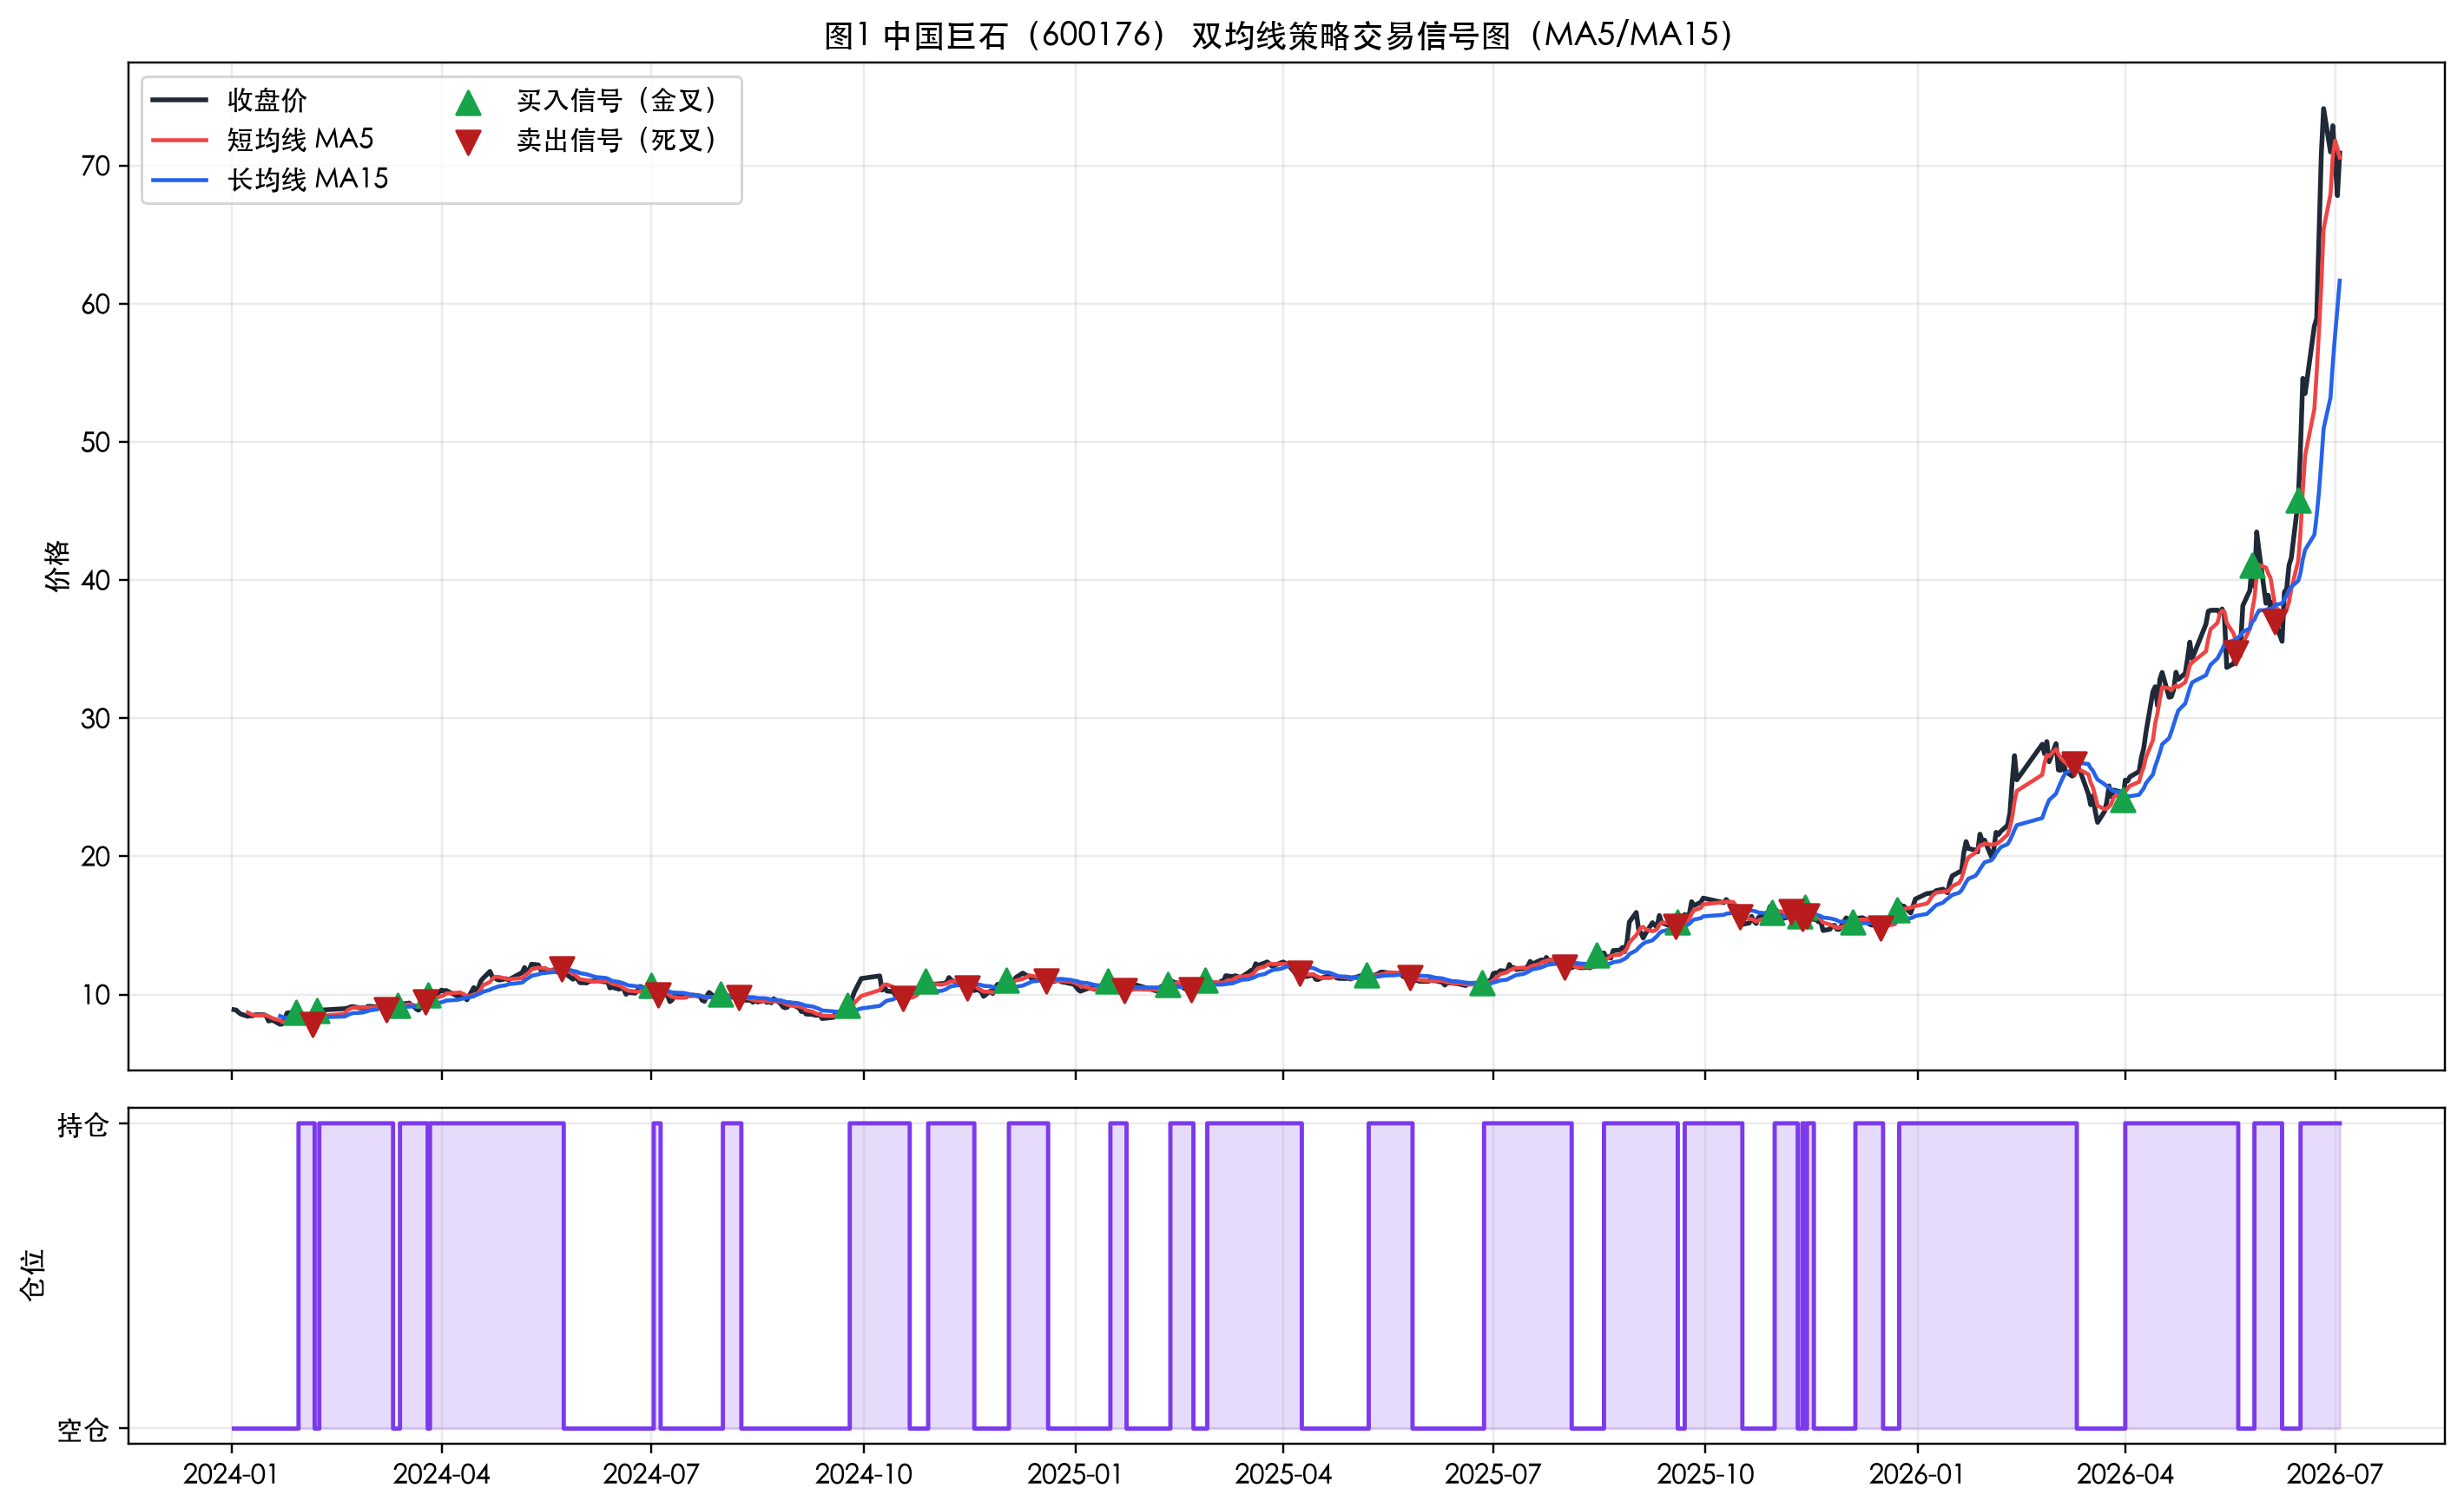

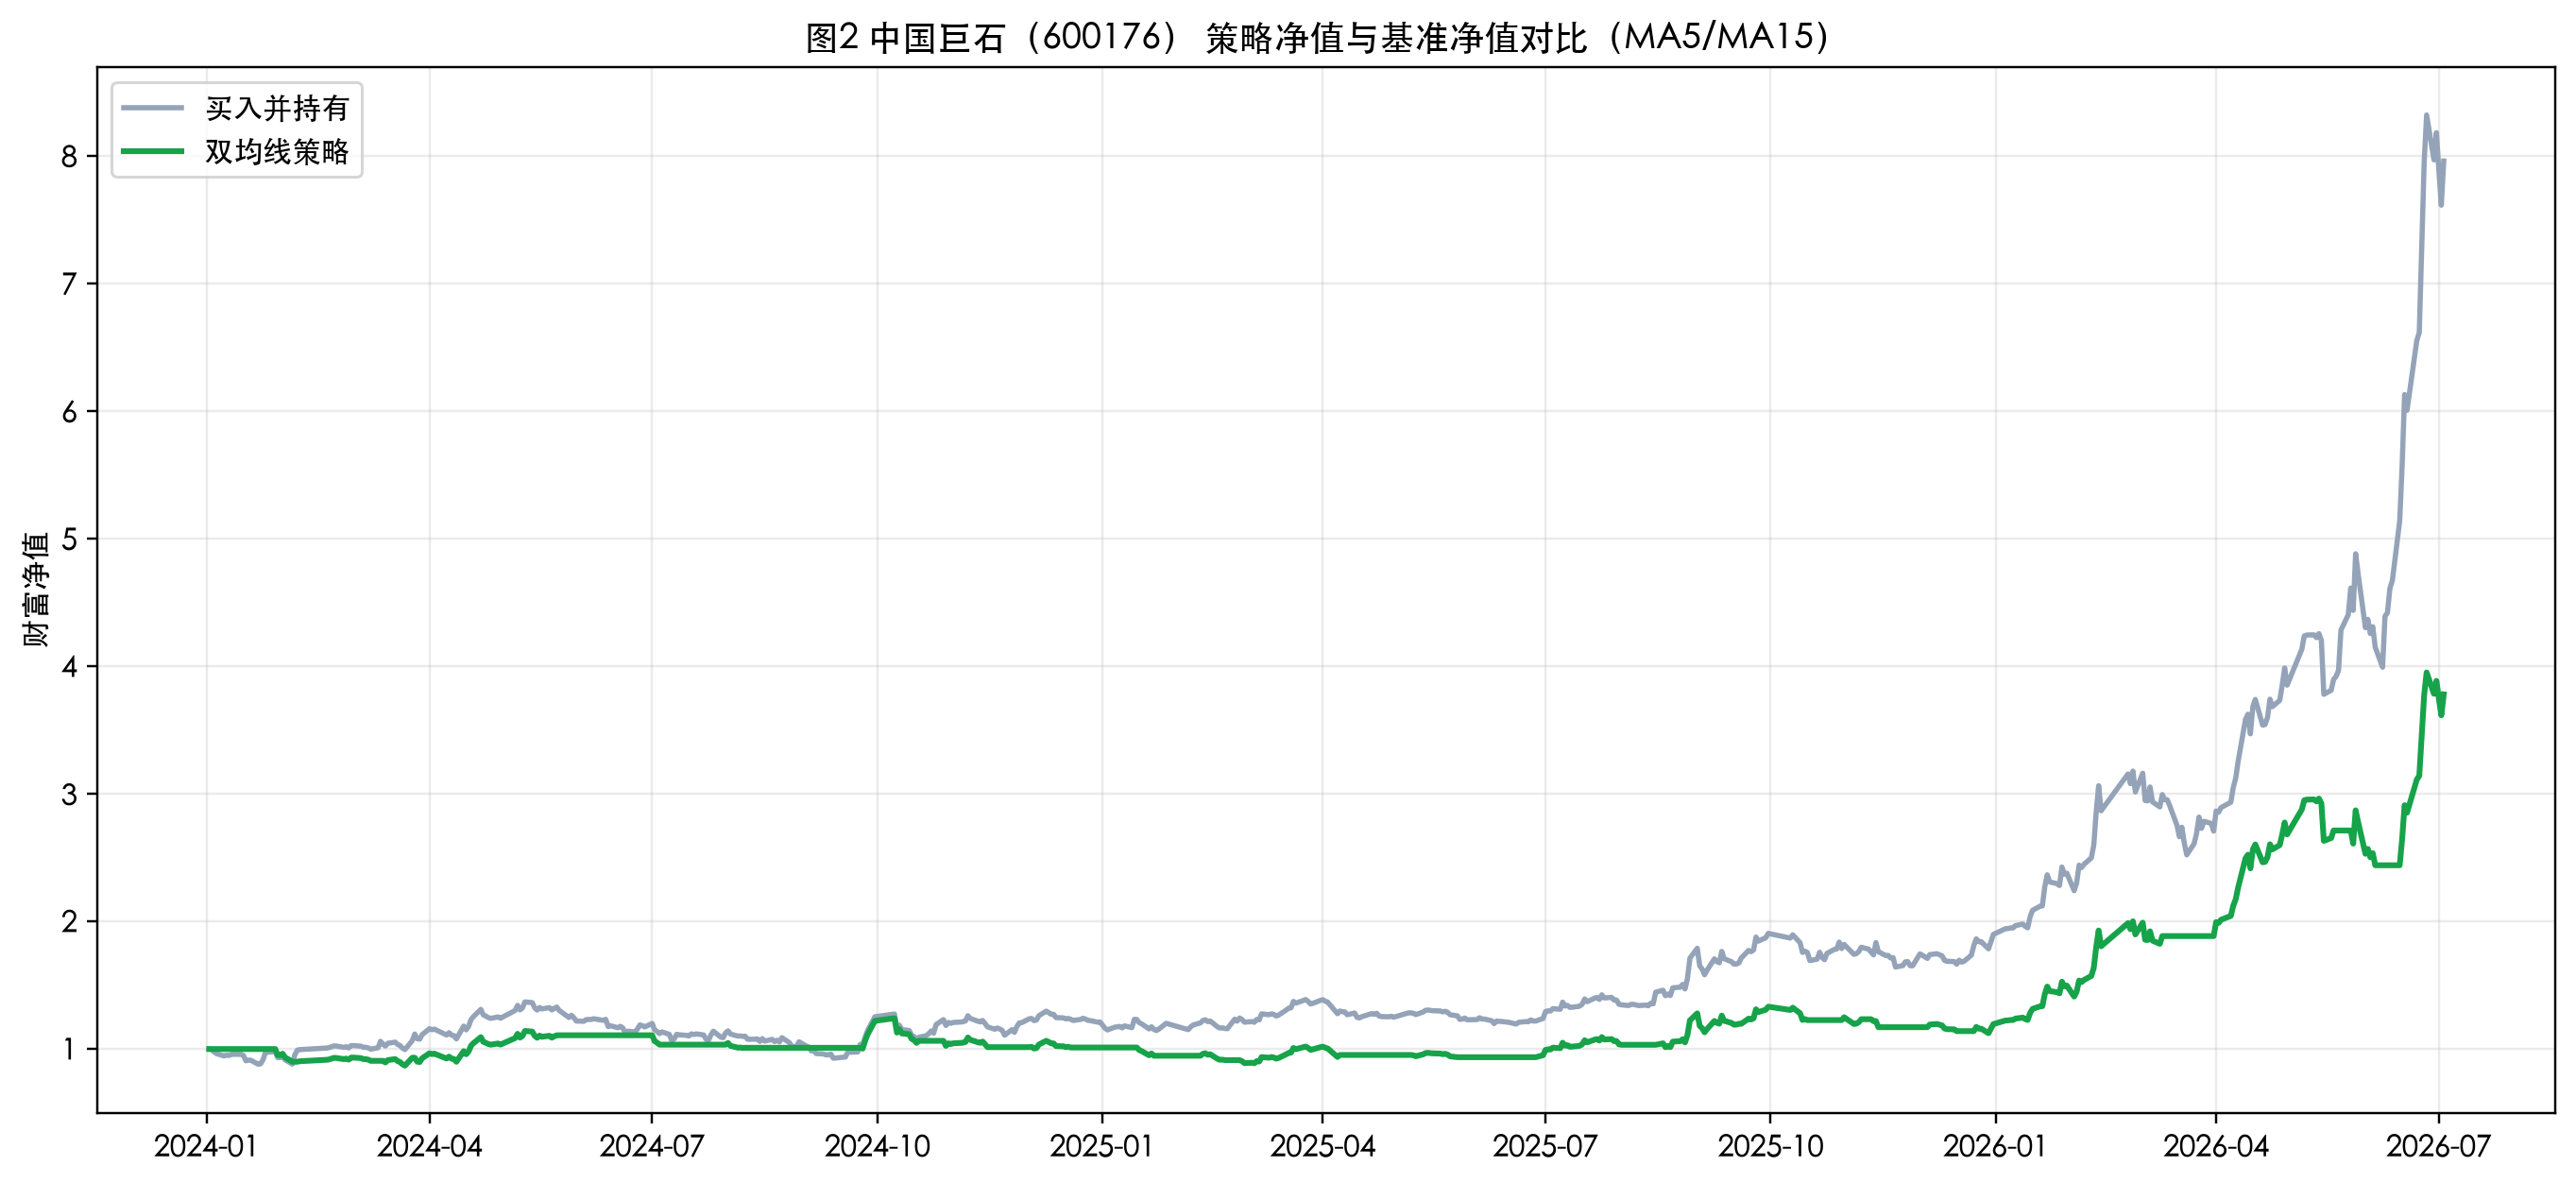

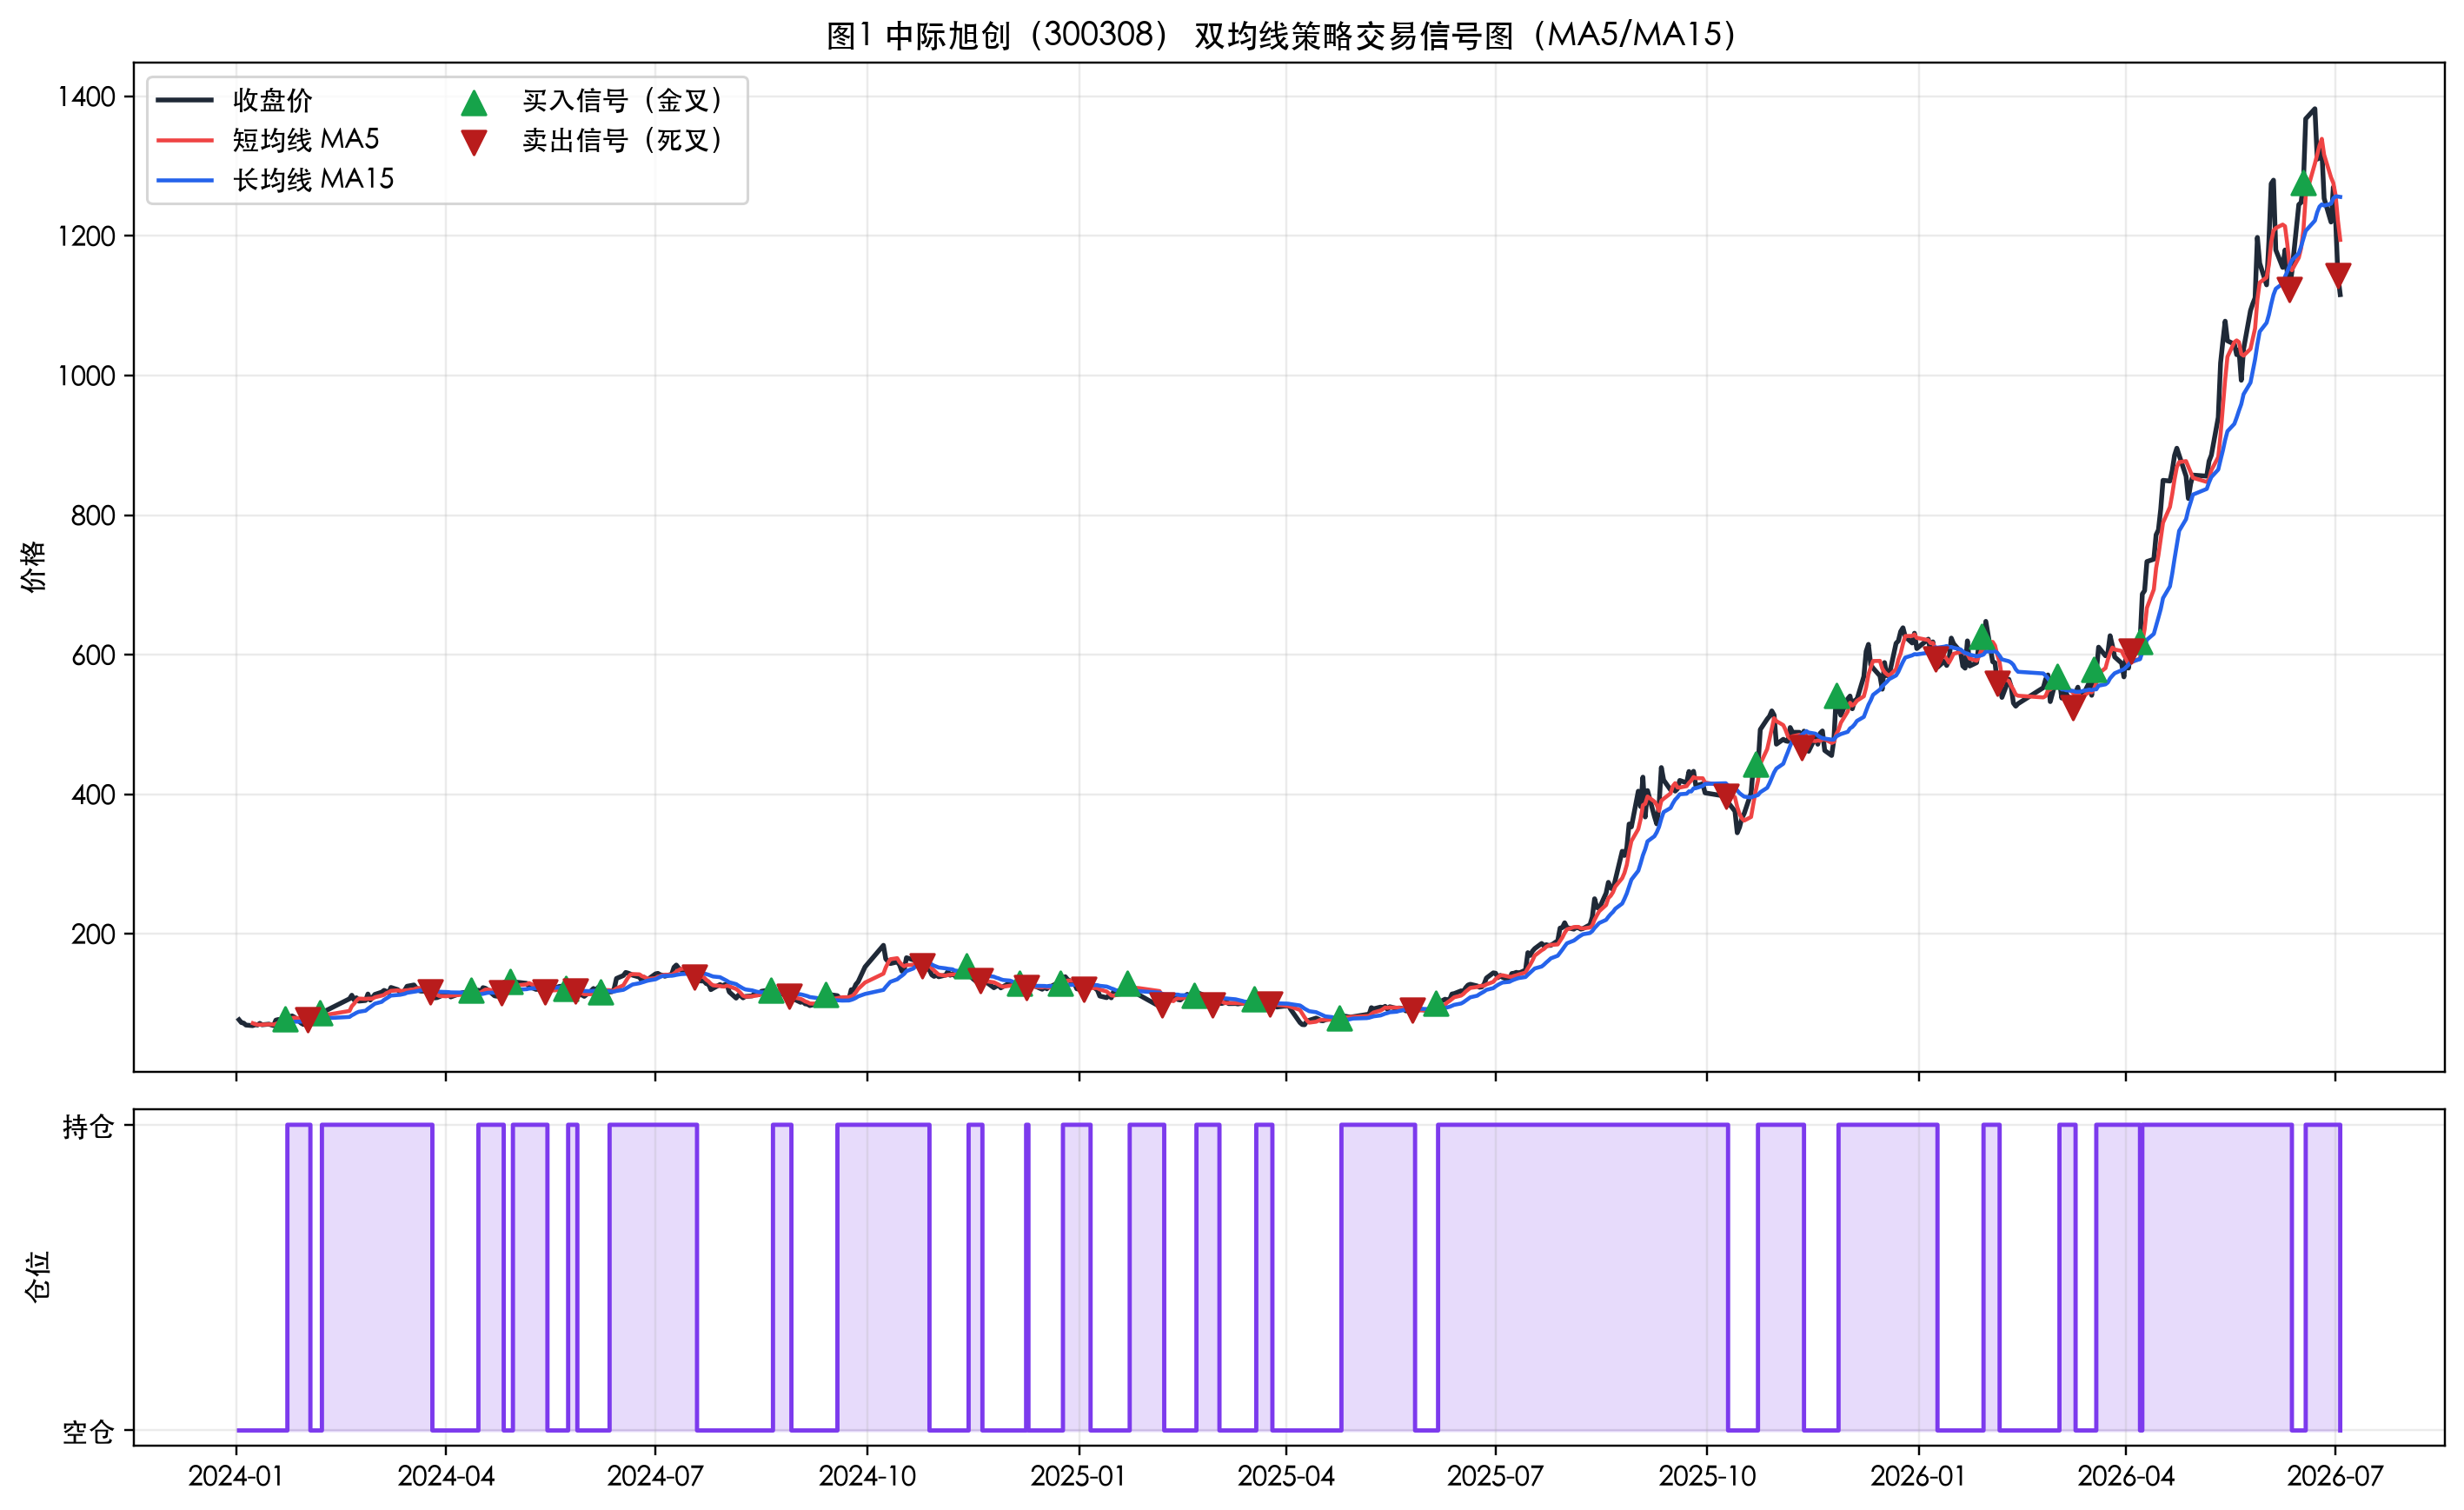

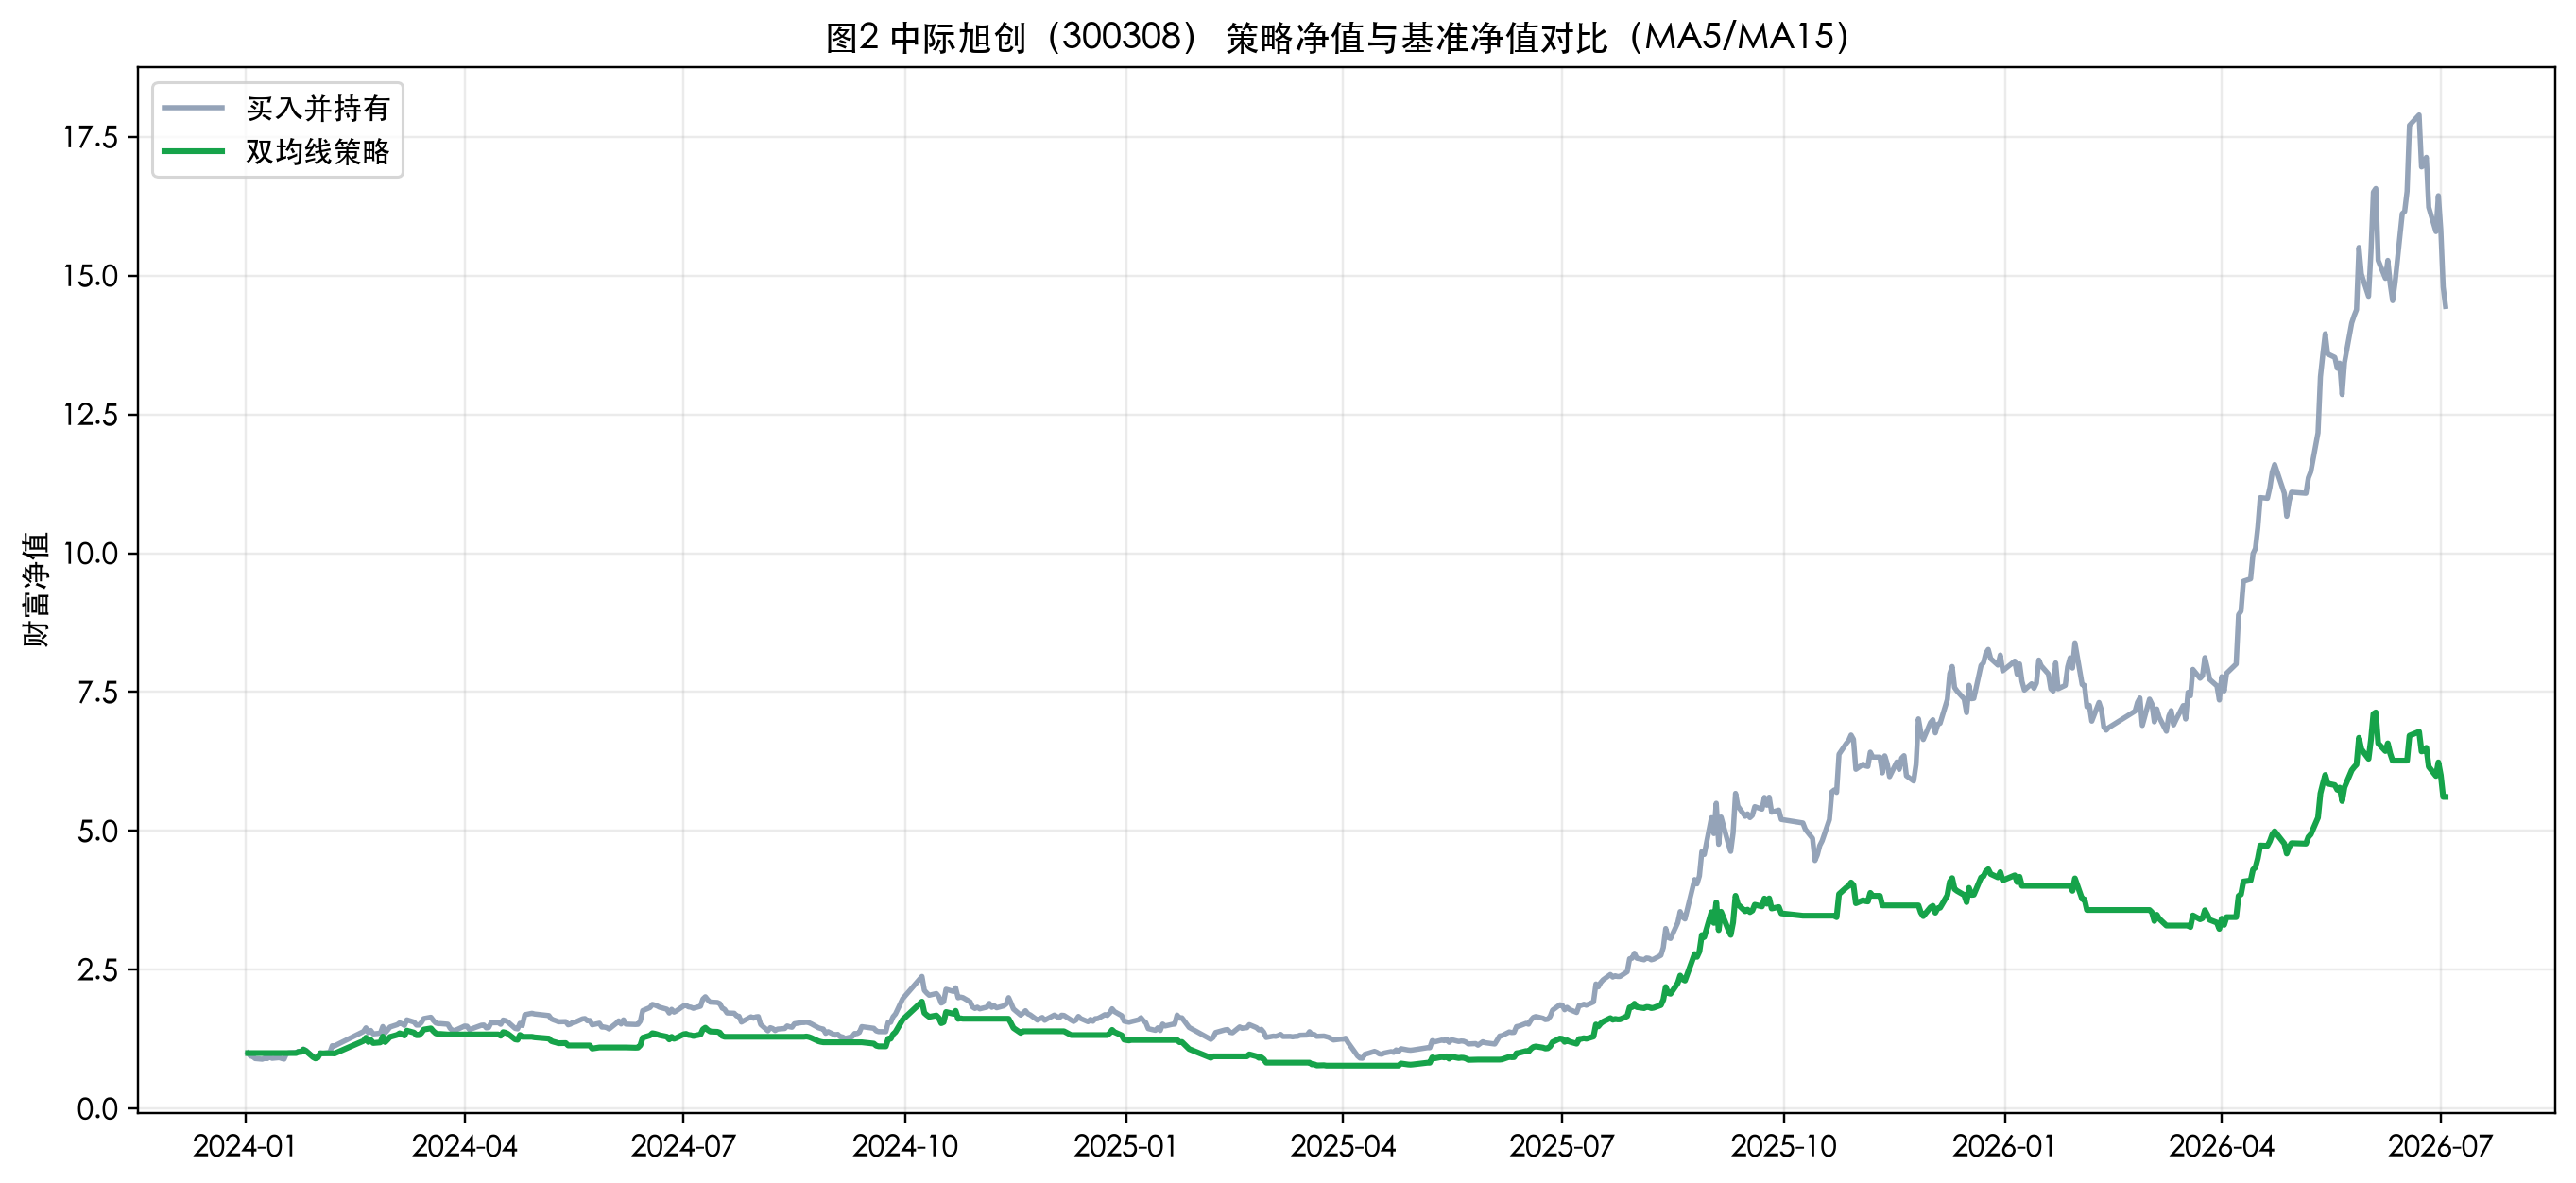

In [4]:
display(Image(filename=str(figures_dir / 'china_jushi_ma_5_15_signals.png')))
display(Image(filename=str(figures_dir / 'china_jushi_ma_5_15_equity.png')))
display(Image(filename=str(figures_dir / 'zhongji_xuchuang_ma_5_15_signals.png')))
display(Image(filename=str(figures_dir / 'zhongji_xuchuang_ma_5_15_equity.png')))

## 4. 不同参数组合比较

为了观察均线周期变化对收益和风险的影响，本次额外测试了 `MA5/20` 与 `MA10/30` 两组参数。

In [5]:
metrics_df[['stock', 'short_window', 'long_window', 'strategy_cumulative_return', 'max_drawdown', 'sharpe_ratio']]

,stock,short_window,long_window,strategy_cumulative_return,max_drawdown,sharpe_ratio
0,中国巨石（600176）,5,15,2.780847,-0.284532,1.646640
1,中国巨石（600176）,5,20,3.745250,-0.218772,1.844390
2,中国巨石（600176）,10,30,3.560435,-0.282270,1.792854
3,中际旭创（300308）,5,15,4.612155,-0.597815,1.515843
4,中际旭创（300308）,5,20,9.915967,-0.522749,1.983015
5,中际旭创（300308）,10,30,6.279032,-0.354481,1.804483


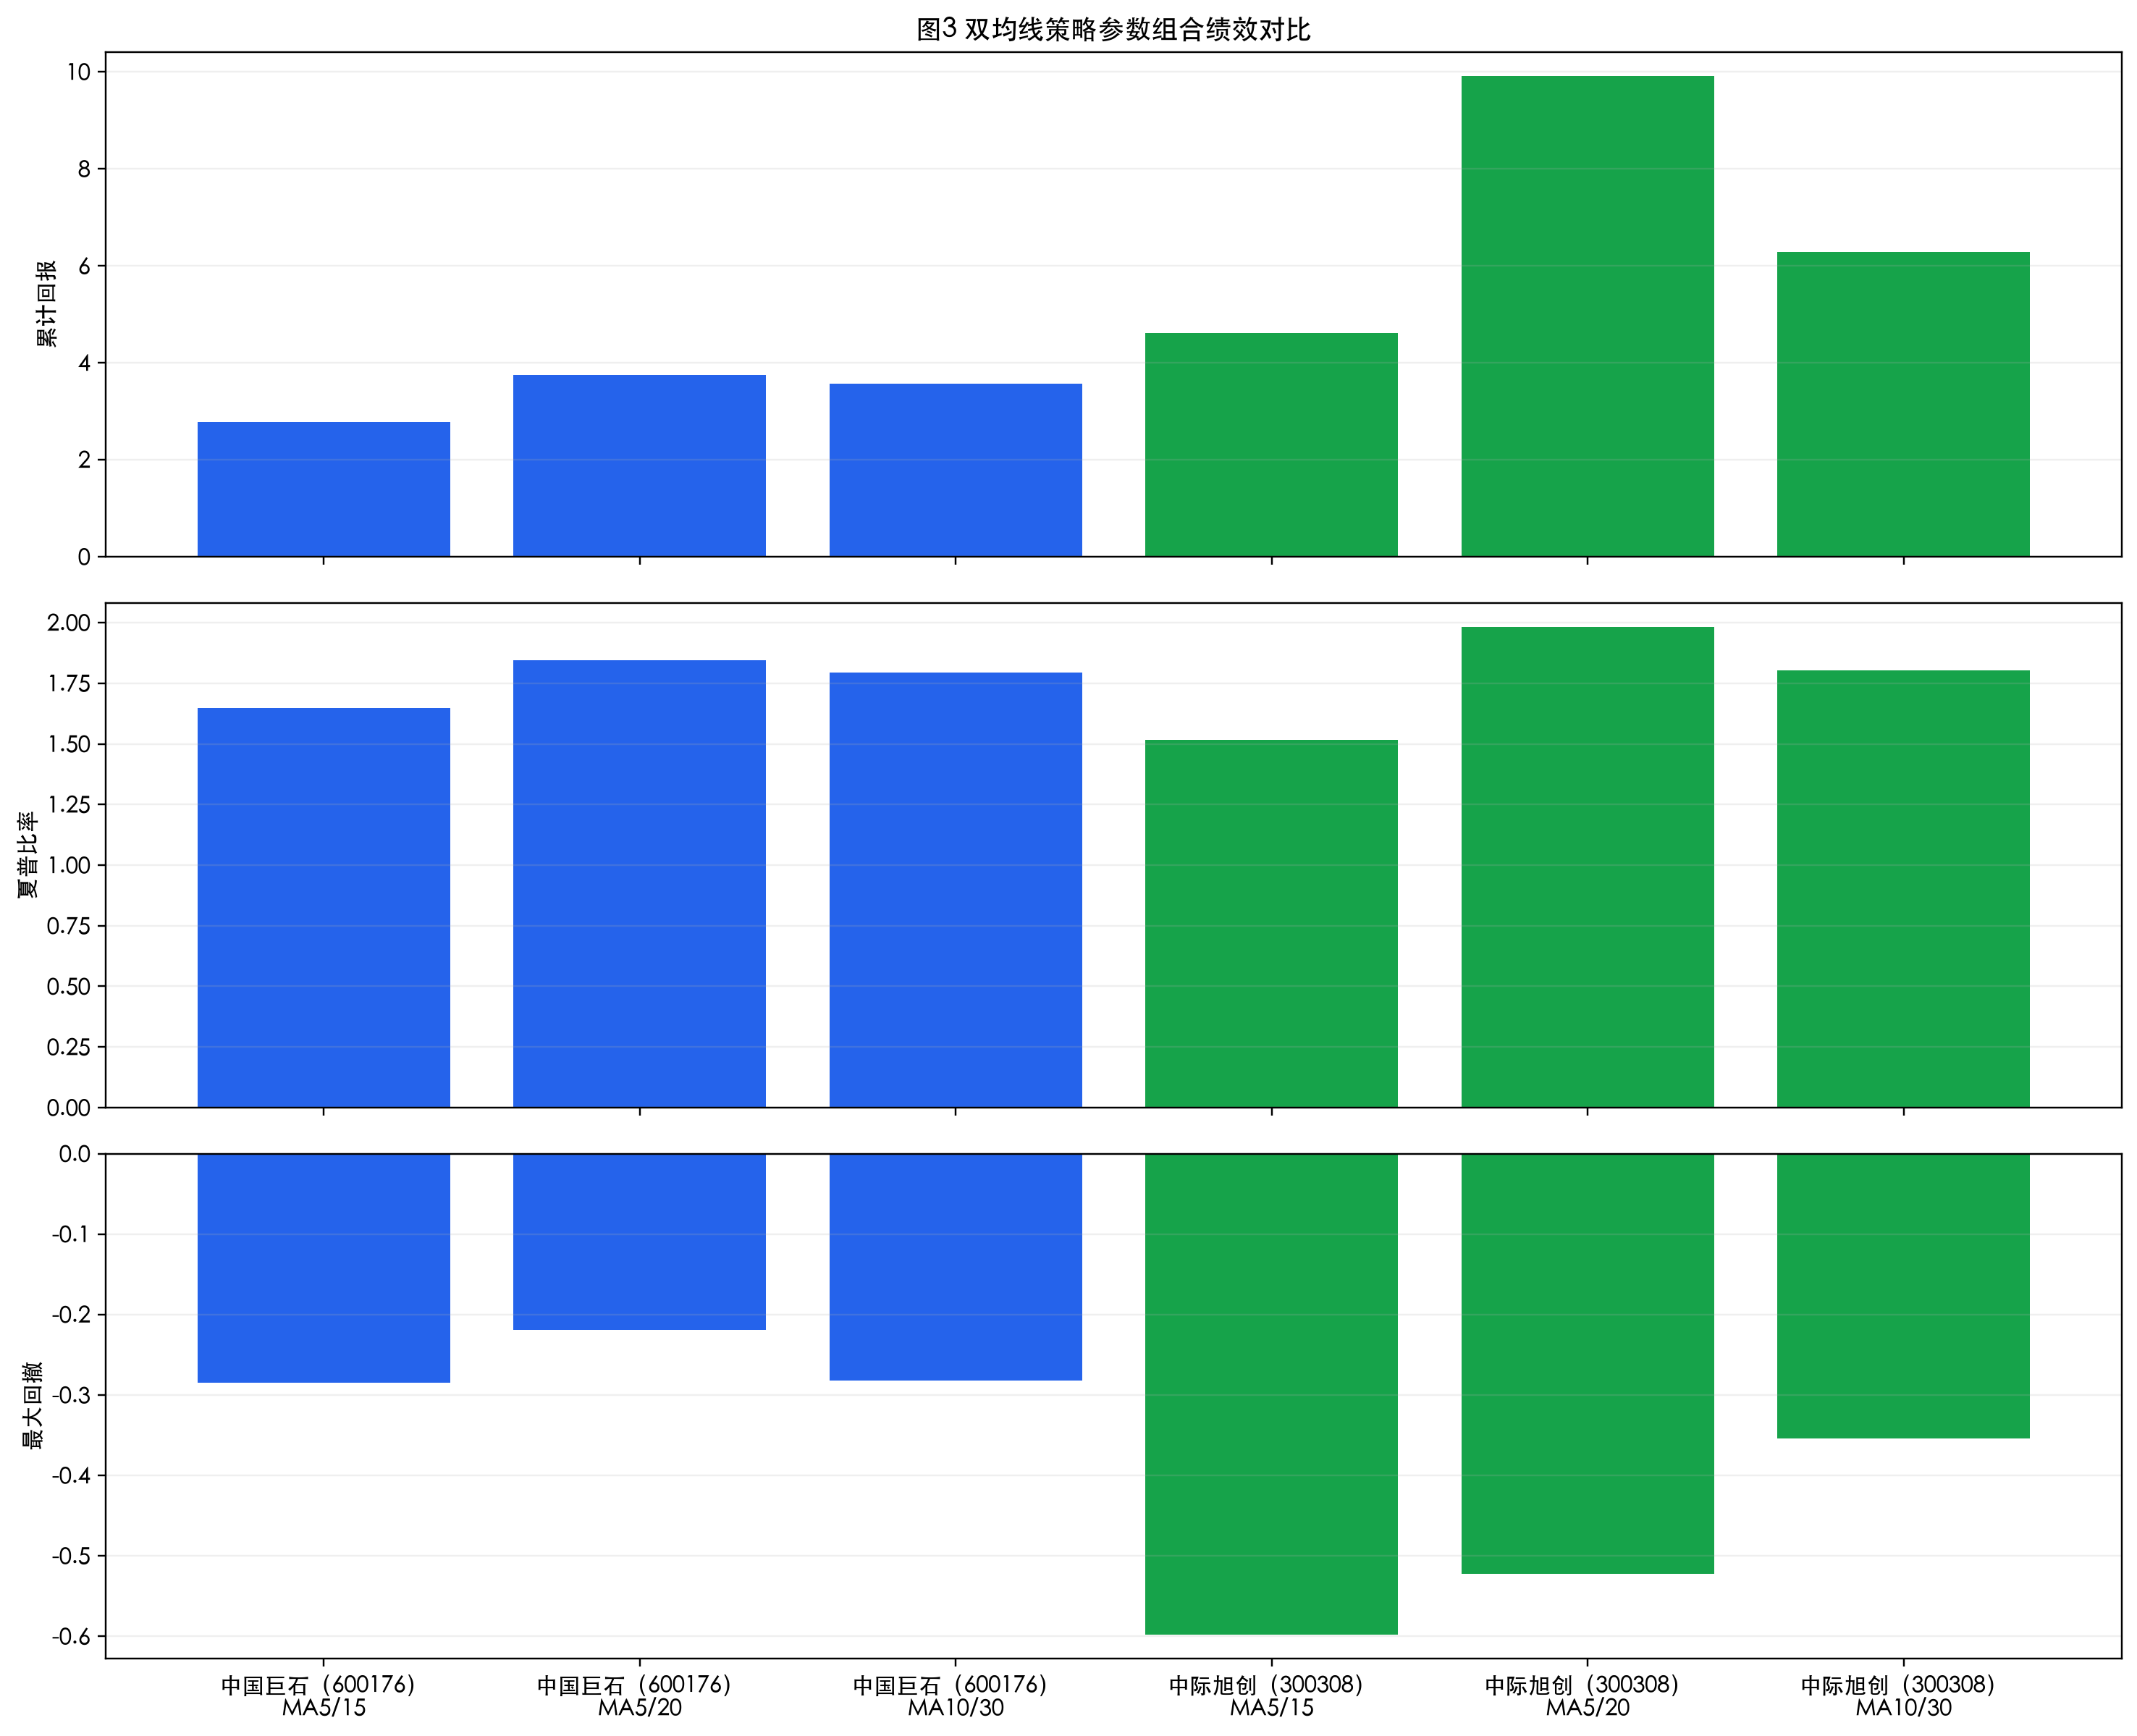

In [6]:
display(Image(filename=str(figures_dir / 'ma_strategy_metric_comparison.png')))

## 5. 观察总结

1. 双均线策略适合趋势明显的区间。
2. 中际旭创在样本期内弹性更强，因此策略收益更高，但回撤也更大。
3. `MA5/20` 在本次样本中整体表现最好，说明适度拉长长均线可以减少噪声干扰。